
---
    Lancement de la création des cohortes | Date : 2022-11-01 00:00:00 | Step : 2.
        ** Cohorte : 1 | Date : 2022-11-01
---
    Lancement du requetage de la base | Date : 2022-11-01.
    Base requetée avec succès | Nombre de lignes : 47502 | Nombre de colonnes : 52
---
---
    Lancement du prétraitement des données.
    Prétraitement des données terminé | Nombre de lignes : 47502 | Nombre de colonnes : 60
---
---
    Lancement de la création des nouveaux indicateurs.
    Création des nouveaux indicateurs terminée | Nombre de lignes : 11110 | Nombre de colonnes : 158
---
---
    Lancement du typage des colonnes.
    Typage des colonnes terminé.
---
        ** Cohorte : 2 | Date : 2023-01-01
---
    Lancement du requetage de la base | Date : 2023-01-01.
    Base requetée avec succès | Nombre de lignes : 48017 | Nombre de colonnes : 52
---
---
    Lancement du prétraitement des données.
    Prétraitement des données terminé | Nombre de lignes : 48017 | Nombre de colonnes : 60
-

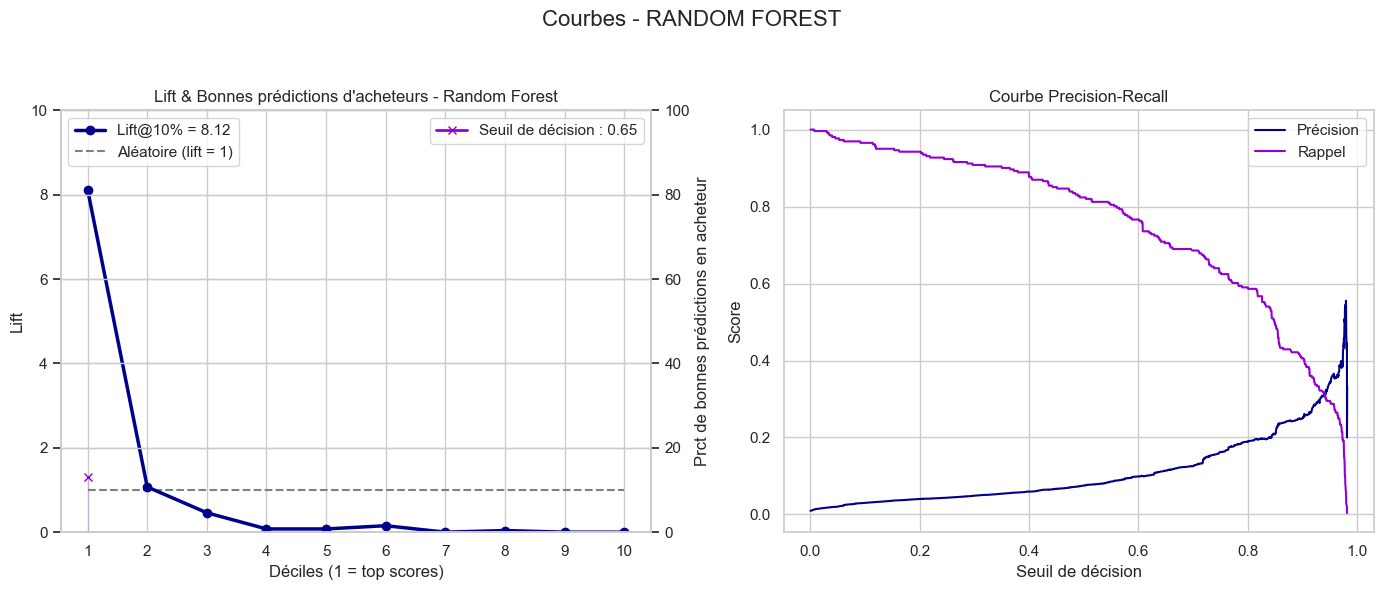

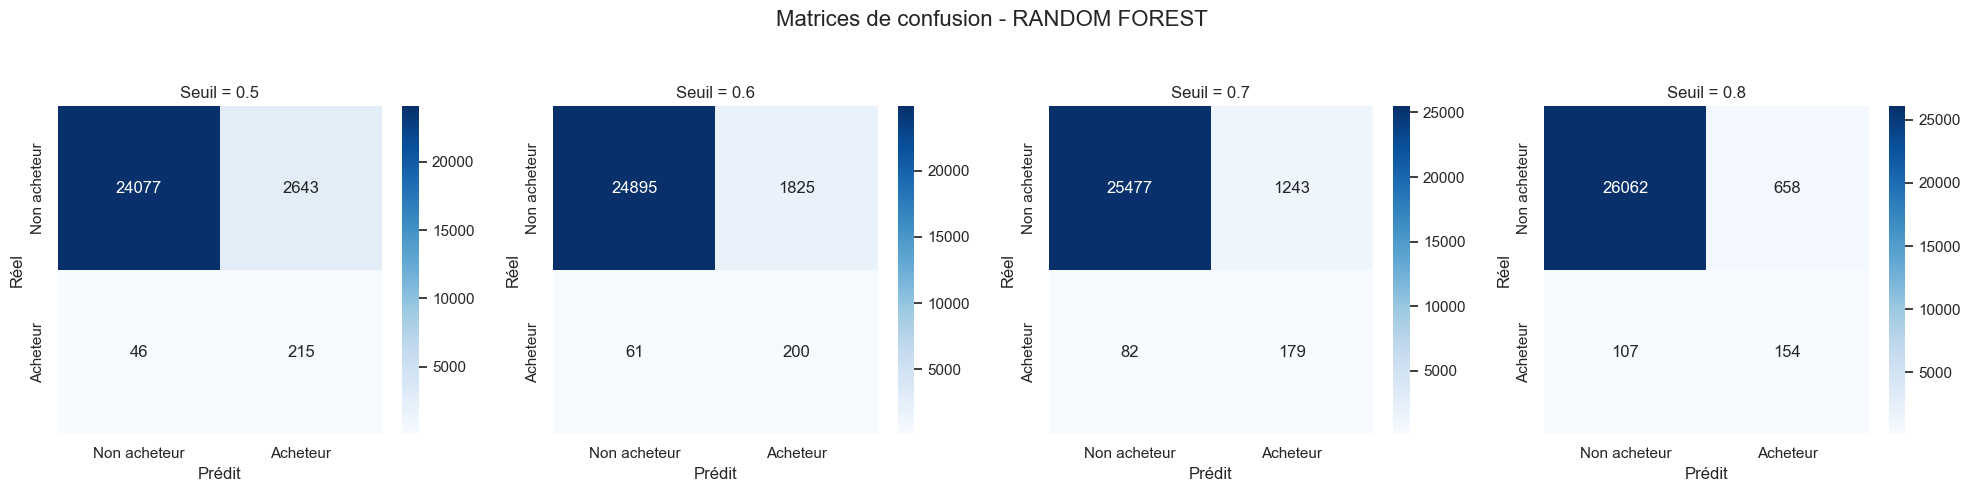

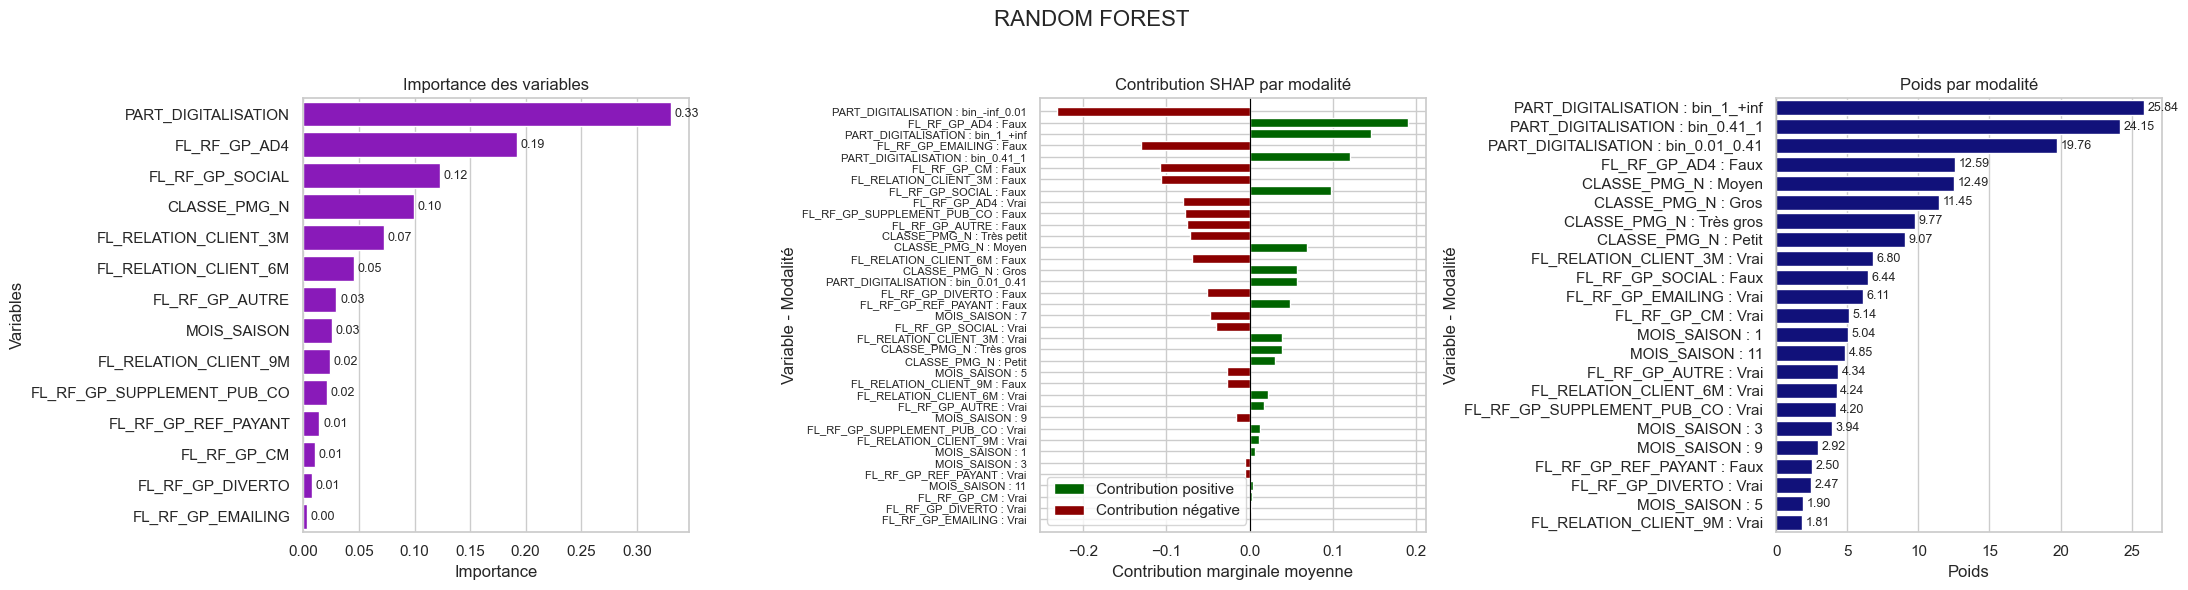

	 Modélisation Random Forest terminée.
---


In [ ]:
# Importations 
## Importation des données
from data.importation.cohorte_class import CohorteBuilder
from data.importation.requetes_importation import get_products

## Préparation des données à la modélisation
from data.prepare_models.data_preparation import DataPreparationPipeline

## Modélisations
from scoring.models import run_models



# Main
if __name__ == "__main__":
    date_seuil_min = datetime.strptime("2022-01-01", "%Y-%m-%d")
    date_seuil_max = datetime.strptime("2024-12-31", "%Y-%m-%d")
    produits = get_products(date=date_seuil_min, product_name="AD4")

    # Database : cohortes saisonnières
    start_date = datetime.strptime("2022-11-01", "%Y-%m-%d")
    CIBLAD = CohorteBuilder(start_date=start_date,
                              produits=produits,
                              lag_prediction=3,
                              cohorte_size=2)
    database = CIBLAD.get_cohortes_system()

    # Préparation des données pour la modélisation  
    pipeline = DataPreparationPipeline(df=database,
                                        target='FL_ACHAT_PRODUIT',
                                        verbose=True,
                                        id_col='_ID_',
                                        max_modalities=5,
                                        woe_threshold=0.2,
                                        criterion='AIC',
                                        business_cols=['CLASSE_PMG_N', 'PART_DIGITALISATION'],
                                        n_splits=5,
                                        threshold_corr=0.7,
                                        threshold_constant=0.99,
                                        nb_max_features=30,
                                        strate='FL_ACHAT_PRODUIT',
                                        sampling_seuil_min=0.075,
                                        sampling_mode='OVER')
    data_train, data_val, data_test, dict_encode_mapping = pipeline.fit_transform(database)


    # Test de modélisation
    models = run_models(data_train=data_train,
                                data_val=data_val,
                                data_test=data_test,
                                target='FL_ACHAT_PRODUIT',
                                model_selected='random_forest', 
                                threshold_decision=0.65,
                                beta=0.5,
                                lift_prct=10
                            )

